# Arrêtez de backtester à l'aveugle.

Vous avez une idée de signal. Instinctivement, vous codez un backtest.   
Résultat : **vous mélangez tout** — le signal, les règles d'entrée/sortie, le sizing, le risk management, les frais, le slippage …   

1) Le backtest invalide ? Impossible de savoir **qui est coupable** :   
le signal était mauvais, ou c'est l'exécution qui a tout cassé ?   

2) Le backtest valide ? Même problème — peut-être que vos règles ont eu de la chance.   
sur un signal qui ne prédit rien du tout.   

### La bonne approche : **valider le signal d'abord, backtester ensuite.**   
  
Avant de coder une seule règle de trading, on pose la question fondamentale :     

> **Mon signal contient-il de l'information sur les rendements futurs ?**.   

C'est l'approche formalisée par **Richard Grinold & Ronald Kahn**.   
avec leur outil central : l'**Information Coefficient (IC)**.   

Ca force également a réfléchir à la théorie derriere la stratégie ;) 

---

**Dans ce notebook :** On va utiliser l'IC avec un exemple concret pour voir si le signal fonctionne !   
    
1. **Les données** — récupérer le BTC/USDT en H4 via l'API Binance.
2. **Le signal** — créer un signal de suivi de tendance (la t-stat OLS rolling).
3. **Est-ce que le signal prédit quelque chose ?** — superposer signal et rendements futurs.
4. **Combien de temps le signal reste utile ?** — trouver l'horizon où le signal prédit le mieux.    
5. **Confirmation visuelle** — confirmer la relation signal → rendement.
6. **Proof of concept : du signal au PnL** — une equity curve naïve.
7. **Conclusion**.

In [1]:
import requests
import pandas as pd
import numpy as np
from pathlib import Path
from scipy import stats
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display

plt.style.use('dark_background')

# ── Constants ──────────────────────────────────────────────────────────────────
LOOKBACK      = 90   # (~15j en H4)

HORIZONS_DAYS = list(range(5, 51, 5))  # [5, 10, ..., 50] — pas de 5j

---
## Partie 1 — Les données

*On récupère le BTC/USDT en H4 via l'API Binance.*

In [2]:
def fetch_binance_klines(symbol: str, interval: str, start: str, end: str) -> pd.DataFrame:
    """Fetch OHLCV from Binance REST API with pagination."""
    url = "https://api.binance.com/api/v3/klines"
    start_ms = int(pd.Timestamp(start).timestamp() * 1000)
    end_ms   = int(pd.Timestamp(end).timestamp()   * 1000)
    
    all_rows = []
    current  = start_ms
    
    while current < end_ms:
        params = {
            "symbol":    symbol,
            "interval":  interval,
            "startTime": current,
            "endTime":   end_ms,
            "limit":     1000,
        }
        resp = requests.get(url, params=params, timeout=10)
        resp.raise_for_status()
        batch = resp.json()
        if not batch:
            break
        all_rows.extend(batch)
        current = batch[-1][0] + 1  # advance past last candle open time
    
    df = pd.DataFrame(all_rows, columns=[
        "open_time", "open", "high", "low", "close", "volume",
        "close_time", "quote_vol", "trades", "taker_base", "taker_quote", "ignore"
    ])
    df["open_time"] = pd.to_datetime(df["open_time"], unit="ms")
    df = df.set_index("open_time").sort_index()
    
    cols = ["open", "high", "low", "close", "volume"]
    df = df[cols].astype(float)
    df.index.name = "datetime"
    return df


CACHE_PATH = Path("btcusdt_4h.parquet")

if CACHE_PATH.exists():
    df = pd.read_parquet(CACHE_PATH)
    if df.index.tz is not None:
        df.index = df.index.tz_localize(None)
else:
    df = fetch_binance_klines("BTCUSDT", "4h", "2021-05-01", "2026-01-01")
    df.to_parquet(CACHE_PATH)

display(df.tail(3))
print(f"Rows: {len(df):,}  |  Period: {df.index[0].date()} → {df.index[-1].date()}")

,open,high,low,close,volume
datetime,,,,,
2025-12-31 16:00:00,87953.97,88053.49,87400.41,87541.85,2936.14316
2025-12-31 20:00:00,87541.85,87879.04,87250.00,87648.22,1581.56113
2026-01-01 00:00:00,87648.21,88088.10,87632.74,87846.02,833.74412


Rows: 10,237  |  Period: 2021-05-01 → 2026-01-01


---
## Partie 2 — Le signal

*Créer un score de momentum normalisé — la t-stat OLS rolling.*

La **t-stat de la pente OLS** sur `log(close)` :
- Elle ajuste la pente par sa propre incertitude statistique
- Quand la t-stat est forte (ex. > 2), la tendance est significativement croissante
- Quand elle est négative, la tendance est significativement baissière
- C'est un signal de **momentum structurel normalisé** par le bruit (pratique en multi actifs)

In [3]:
from statsmodels.regression.rolling import RollingOLS
from bokeh.plotting import figure, show
from bokeh.layouts import column
from bokeh.io import output_notebook
from bokeh.io import curdoc

output_notebook()
curdoc().theme = "dark_minimal"

log_close = np.log(df["close"])
X = sm.add_constant(np.arange(len(log_close), dtype=float))

results = RollingOLS(log_close, X, window=LOOKBACK).fit()
signal = results.tvalues.iloc[:, 1].rename("tstat")

x   = df.index
sig = signal.fillna(0)

Loading BokehJS ...

In [4]:
# Affichage
p1 = figure(
    height=300, sizing_mode="stretch_width",
    x_axis_type="datetime",
    title="BTC/USDT H4 — Prix",
    tools="pan,wheel_zoom,box_zoom,reset,save",
    active_scroll="wheel_zoom",
)
p1.line(x, df["close"], color="#f0a500", line_width=0.9, legend_label="BTC/USDT")
p1.yaxis.axis_label = "Prix (USDT)"
p1.legend.location  = "top_left"

p2 = figure(
    height=220, sizing_mode="stretch_width",
    x_axis_type="datetime",
    x_range=p1.x_range,
    title="Signal OLS Rolling t-stat",
    tools="pan,wheel_zoom,box_zoom,reset,save",
    active_scroll="wheel_zoom",
)
p2.varea(x=x, y1=0,           y2=sig.clip(lower=0), color="#00c853", alpha=0.6, legend_label="t-stat > 0")
p2.varea(x=x, y1=sig.clip(upper=0), y2=0,           color="#d50000", alpha=0.6, legend_label="t-stat ≤ 0")
p2.line( x=x, y=np.zeros(len(x)), color="white", line_width=0.8, line_dash="dashed")
p2.yaxis.axis_label = "t-stat"
p2.xaxis.axis_label = "Date"
p2.legend.location  = "top_left"

show(column(p1, p2, sizing_mode="stretch_width"))

---
## Partie 3 — Est-ce que le signal prédit quelque chose ?

*Superposer signal et rendements futurs pour un premier coup d'œil.*

On visualise directement la relation entre le signal et les rendements forward :
- Comment évolue la t-stat dans le temps ?
- Les rendements forward suivent-ils la même direction ?

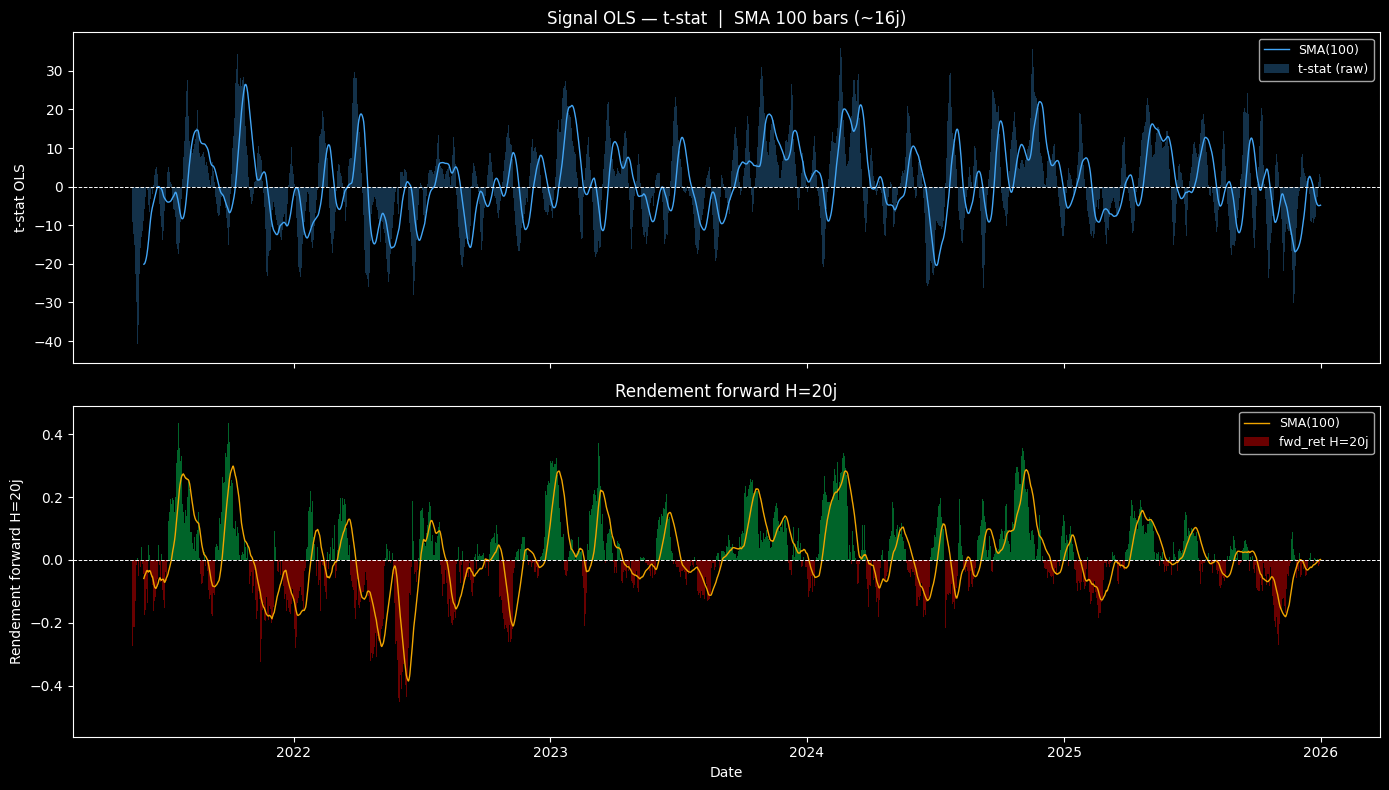

In [5]:
def fwd_return(close: pd.Series, days: float) -> pd.Series:
    """Log forward return en cherchant le prix réel à t + timedelta(days)."""
    delta = pd.Timedelta(days=days)
    future_prices = close.reindex(close.index + delta, method="nearest").to_numpy()
    return pd.Series(np.log(future_prices / close.to_numpy()), index=close.index)

SMA_WIN       = 100  # ~17 jours en H4
DEFAULT_H     = 20   # horizon par défaut pour cette partie

# Forward returns pour tous les horizons
fwd_rets = {h: fwd_return(df["close"], h) for h in HORIZONS_DAYS}

fwd_ret_default = fwd_rets[DEFAULT_H]
combined = pd.concat(
    [signal.rename("signal"), fwd_ret_default.rename("fwd_ret")], axis=1
).dropna()

# — Visualisation : 2 subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

common_idx = combined.index

# ax1 : Signal OLS (t-stat)
sig_vals = combined["signal"]
ax1.bar(common_idx, sig_vals.values, color="#42a5f5", alpha=0.3,
        width=pd.Timedelta(hours=4), label="t-stat (raw)")
ax1.plot(common_idx, sig_vals.rolling(SMA_WIN).mean(),
         color="#42a5f5", linewidth=1, label=f"SMA({SMA_WIN})")
ax1.axhline(0, color="white", linewidth=0.7, linestyle="--")
ax1.set_ylabel("t-stat OLS")
ax1.set_title(f"Signal OLS — t-stat  |  SMA {SMA_WIN} bars (~{SMA_WIN // 6}j)")
ax1.legend(fontsize=9)

# ax2 : fwd_ret
fwd_vals = combined["fwd_ret"]
bar_colors = ["#00c853" if v > 0 else "#d50000" for v in fwd_vals.values]
ax2.bar(common_idx, fwd_vals.values, color=bar_colors, alpha=0.5,
        width=pd.Timedelta(hours=4), label=f"fwd_ret H={DEFAULT_H}j")
ax2.plot(common_idx, fwd_vals.rolling(SMA_WIN).mean(),
         color="#f0a500", linewidth=1, label=f"SMA({SMA_WIN})")
ax2.axhline(0, color="white", linewidth=0.7, linestyle="--")
ax2.set_ylabel(f"Rendement forward H={DEFAULT_H}j")
ax2.set_title(f"Rendement forward H={DEFAULT_H}j")
ax2.set_xlabel("Date")
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

### Corrélation de Spearman — Comment ça marche ?

La corrélation de Pearson classique mesure la relation **linéaire** entre deux variables brutes.
Problème : elle est sensible aux outliers et suppose une relation linéaire.

**Spearman** contourne ça en 2 étapes :

> **Étape 1 — Ranger** : on remplace chaque valeur par son **rang** (1 = plus petit, N = plus grand)    
> **Étape 2 — Corréler les rangs** : on calcule la corrélation sur les rangs.

La question devient : **quand le signal est classé "fort", le rendement est-il aussi classé "fort" ?**

---

#### Exemple concret — 5 observations

| Obs | Signal (brut) | Rang signal | Rendement (brut) | Rang rendement |
|:---:|:---:|:---:|:---:|:---:|
| A | 0.8 | 2 | +3.1% | 3 |
| B | 2.5 | 4 | +7.0% | 5 |
| C | 0.3 | 1 | +1.2% | 1 |
| D | 1.9 | 3 | +2.8% | 2 |
| E | 3.1 | 5 | +5.4% | 4 |

**Étape 1** — On ignore les valeurs brutes, on ne garde que les rangs :

**Étape 2** — On calcule la corrélation de **Pearson sur ces rangs**.   

---

**Pourquoi c'est utile ?**   
On ne demande PAS au signal de prédire le rendement exact.      
On demande juste : **est-ce que les "gros" signaux correspondent aux "gros" rendements ?**   



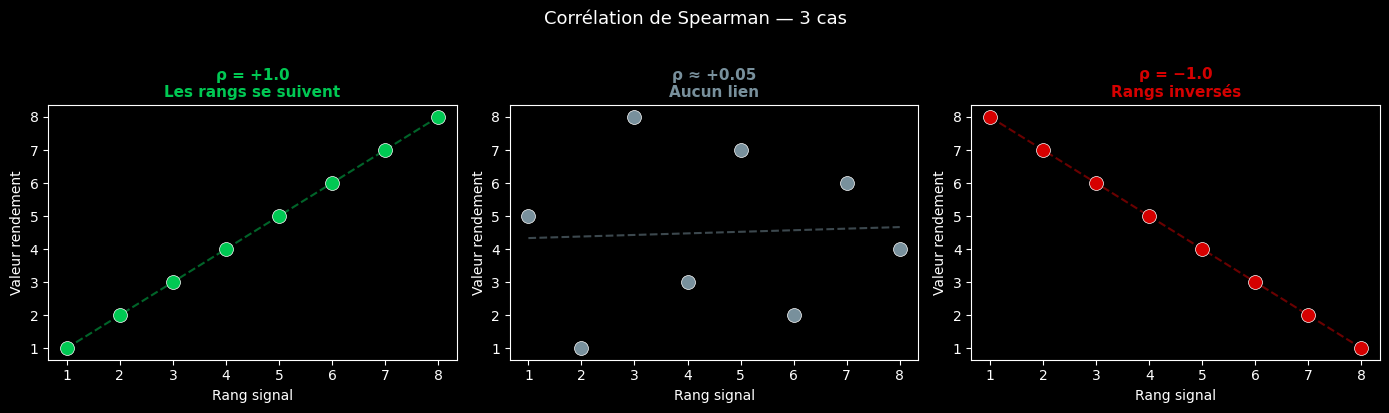

In [7]:
# ── Mini exemple : Spearman en 3 cas ──────────────────────────────────────────
n = 8
x = np.arange(1, n + 1)

# Cas 1 : monotone croissant
y_pos = np.array([1, 2, 3, 4, 5, 6, 7, 8], dtype=float)

# Cas 2 : aucun lien
y_zero = np.array([5, 1, 8, 3, 7, 2, 6, 4], dtype=float)

# Cas 3 : monotone décroissant
y_neg = np.array([8, 7, 6, 5, 4, 3, 2, 1], dtype=float)

rho_zero = stats.spearmanr(x, y_zero).statistic

cases = [
    (x, y_pos,  "#00c853", "ρ = +1.0\nLes rangs se suivent"),
    (x, y_zero, "#78909c", f"ρ ≈ {rho_zero:+.2f}\nAucun lien"),
    (x, y_neg,  "#d50000", "ρ = −1.0\nRangs inversés"),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (xv, yv, color, title) in zip(axes, cases):
    ax.scatter(xv, yv, color=color, s=100, zorder=5, edgecolors="white", linewidths=0.5)

    # Ligne de tendance
    coeffs = np.polyfit(xv, yv, 1)
    ax.plot(xv, np.polyval(coeffs, xv), color=color, linewidth=1.5, alpha=0.5, linestyle="--")

    ax.set_title(title, fontsize=11, color=color, fontweight="bold")
    ax.set_xlabel("Rang signal")
    ax.set_ylabel("Valeur rendement")

fig.suptitle("Corrélation de Spearman — 3 cas", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
### On mesure — l'Information Coefficient

*Le Spearman entre le signal et le rendement forward : un seul chiffre pour résumer le pouvoir prédictif.*

On calcule le Spearman entre le signal et le rendement forward à H=20j.

In [8]:
# ── IC global : Spearman sur signal complet, horizon = 20j ────────────────────
ic, pval = stats.spearmanr(combined["signal"], combined["fwd_ret"])
n_obs = len(combined)

print(f"IC (Spearman)  : {ic:.4f}")
print(f"Observations   : {n_obs:,}")

IC (Spearman)  : 0.0631
Observations   : 10,148


  | IC | Interprétation |
  |---|---|
  | 0.00 | Aucun pouvoir prédictif |
  | <span style="color:#00c853">0.02 à 0.05</span> | Faible, mais exploitable |
  | <span style="color:#00c853">0.05 à 0.10</span> | Bon signal |
  | <span style="color:#00c853">> 0.20</span> | Suspect

---
## Partie 4 — Combien de temps le signal reste utile ?

*L'IC Decay montre la "durée de vie" du signal — à quel horizon il prédit, et quand il expire.*

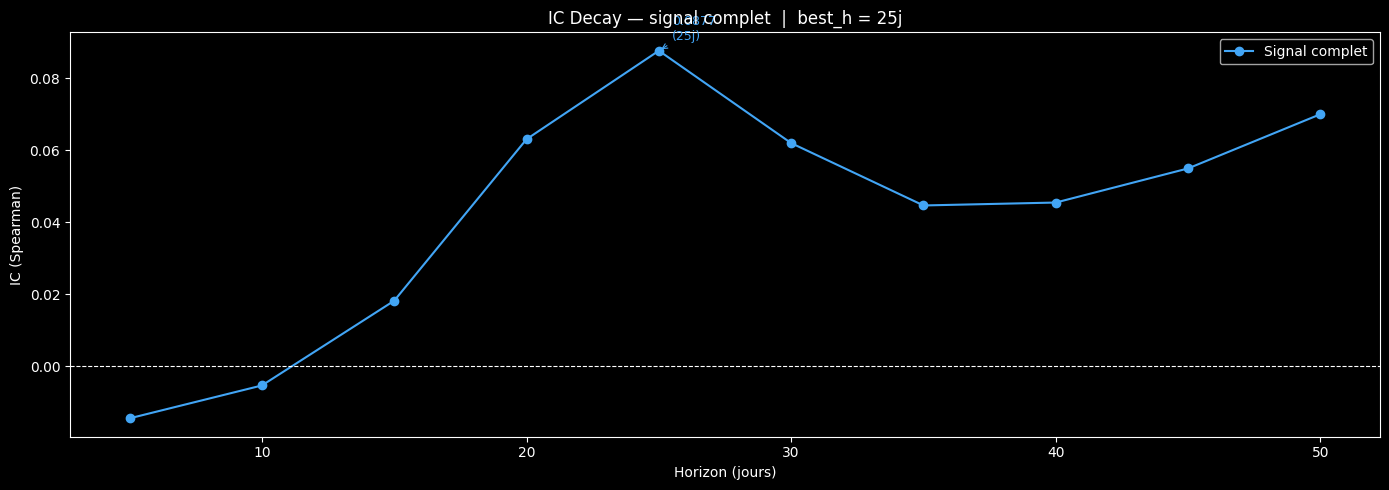

In [9]:
# ── IC Decay — signal complet ──────────────────────────────────────────────────
ic_decay = []

for h in HORIZONS_DAYS:
    comb = pd.concat([signal.rename("s"), fwd_rets[h].rename("f")], axis=1).dropna()
    ic_h, _ = stats.spearmanr(comb["s"], comb["f"]) if len(comb) > 10 else (np.nan, None)
    ic_decay.append(ic_h)

ic_decay = np.array(ic_decay)

# best_h = horizon au pic
best_h = HORIZONS_DAYS[int(np.nanargmax(ic_decay))]

# Reconstruire combined avec best_h pour les parties suivantes
fwd_ret_best = fwd_rets[best_h]
combined = pd.concat(
    [signal.rename("signal"), fwd_ret_best.rename("fwd_ret")], axis=1
).dropna()

# ── Visualisation IC Decay ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(HORIZONS_DAYS, ic_decay, color="#42a5f5", marker="o",
        linewidth=1.5, label="Signal complet")
ax.axhline(0, color="white", linewidth=0.8, linestyle="--")

# annotation peak
valid = np.where(~np.isnan(ic_decay))[0]
if len(valid):
    pk = valid[np.argmax(ic_decay[valid])]
    ax.annotate(f"{ic_decay[pk]:.4f}\n({HORIZONS_DAYS[pk]}j)",
                xy=(HORIZONS_DAYS[pk], ic_decay[pk]),
                xytext=(HORIZONS_DAYS[pk] + 0.5, ic_decay[pk] + 0.003),
                fontsize=9, color="#42a5f5",
                arrowprops=dict(arrowstyle="->", color="#42a5f5", lw=0.8))

ax.set_title(f"IC Decay — signal complet  |  best_h = {best_h}j", fontsize=12)
ax.set_xlabel("Horizon (jours)")
ax.set_ylabel("IC (Spearman)")
ax.legend()
plt.tight_layout()
plt.show()

---
## Partie 5 — Confirmation visuelle

*La pente de régression signal → rendement confirme ce que l'IC résume en un chiffre.*

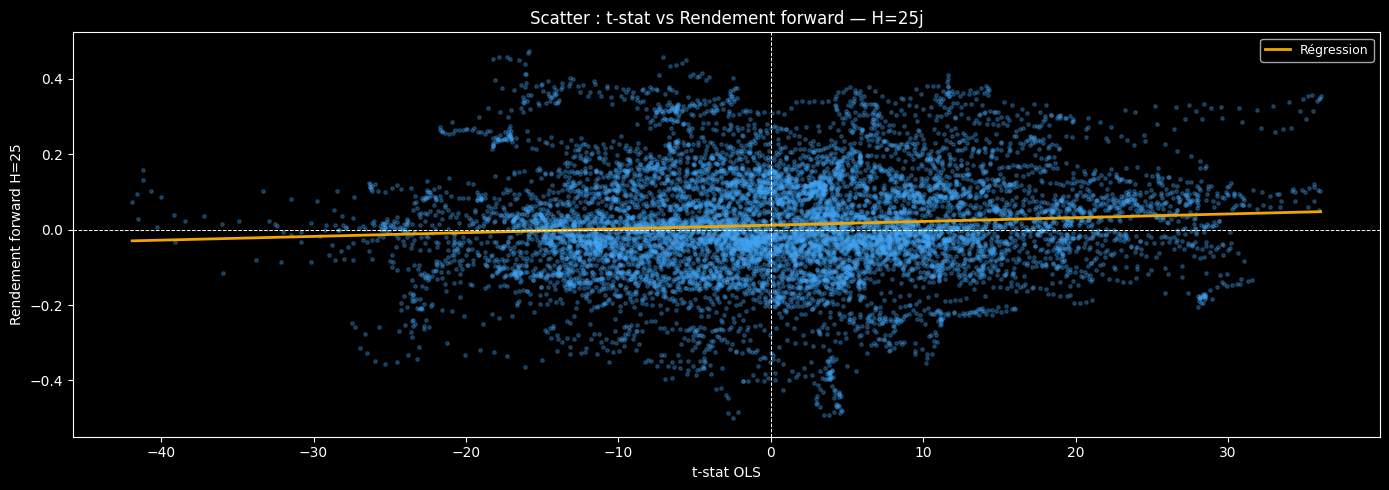

In [10]:
# Scatter — signal complet vs rendement forward
fig, ax = plt.subplots(figsize=(14, 5))
ax.scatter(combined["signal"], combined["fwd_ret"], alpha=0.3, s=6, color="#42a5f5")
coeffs = np.polyfit(combined["signal"], combined["fwd_ret"], 1)
x_line = np.linspace(combined["signal"].min(), combined["signal"].max(), 200)
ax.plot(x_line, np.polyval(coeffs, x_line), color="#f0a500", linewidth=2, label="Régression")
ax.axhline(0, color="white", linewidth=0.7, linestyle="--")
ax.axvline(0, color="white", linewidth=0.7, linestyle="--")
ax.set_title(f"Scatter : t-stat vs Rendement forward — H={best_h}j", fontsize=12)
ax.set_xlabel("t-stat OLS")
ax.set_ylabel(f"Rendement forward H={best_h}")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

---
## Partie 6 — Du signal au PnL

*Même une implémentation naïve (exposition linéaire, zéro risk management) montre que le signal IC-positif se convertit en PnL.*.  

**Activation linéaire** : l'exposition rampe de 0 à 1 entre un seuil bas et un seuil haut :   

**Rebalancing avec seuil** : on ne change le poids que si l'écart entre l'exposition cible et l'exposition courante dépasse `REBAL_THRESHOLD`.    
Ça évite de rebalancer à chaque barre 4H pour des micro-variations du signal.

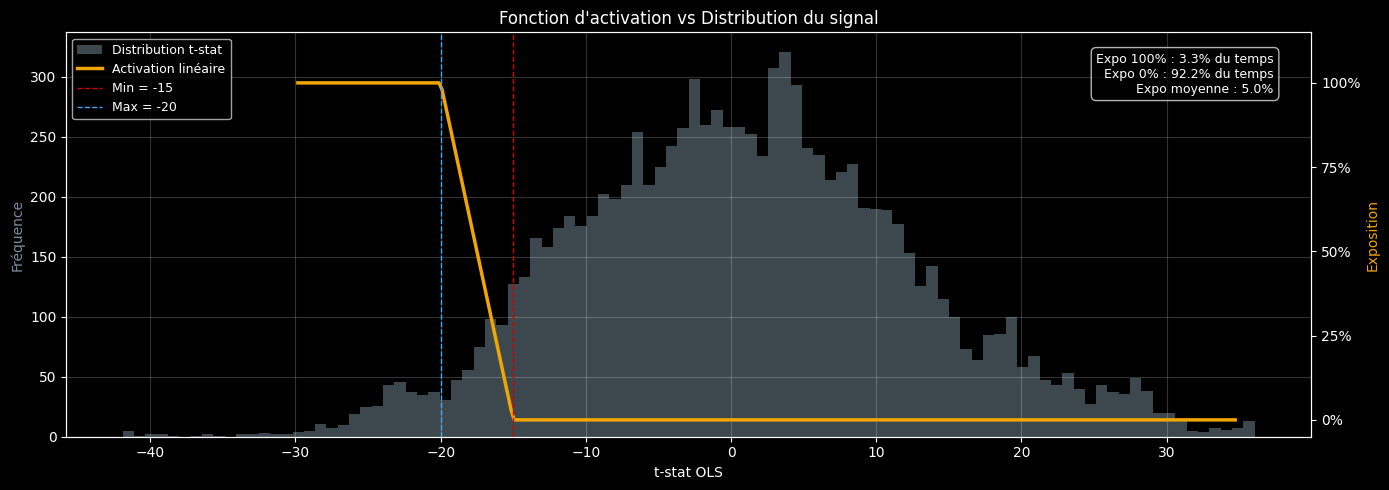

In [15]:
# ── Calibration de la fonction d'activation ───────────────────────────────────
TSTAT_MIN = -15   # tstat à laquelle exposure = 0 %
TSTAT_MAX = -20   # tstat à laquelle exposure = 100 %

sig_all = signal.dropna()

fig, ax1 = plt.subplots(figsize=(14, 5))

# Histogramme sur l'axe gauche
ax1.hist(sig_all.values, bins=100, color="#78909c", alpha=0.5, edgecolor="none",
         label="Distribution t-stat")
ax1.set_xlabel("t-stat OLS")
ax1.set_ylabel("Fréquence", color="#78909c")

# Fonction d'activation sur l'axe droit — couvre toute la plage min/max
ax2 = ax1.twinx()
x_lo = min(TSTAT_MIN, TSTAT_MAX, sig_all.quantile(0.01)) * 1.2
x_hi = max(TSTAT_MIN, TSTAT_MAX, sig_all.quantile(0.99)) * 1.2
x_act = np.linspace(x_lo, x_hi, 300)
y_act = np.clip((x_act - TSTAT_MIN) / (TSTAT_MAX - TSTAT_MIN), 0, 1)
ax2.plot(x_act, y_act, color="#f0a500", linewidth=2.5, label="Activation linéaire")
ax2.axvline(TSTAT_MIN, color="#d50000", linewidth=1, linestyle="--",
            label=f"Min = {TSTAT_MIN}")
ax2.axvline(TSTAT_MAX, color="#42a5f5", linewidth=1, linestyle="--",
            label=f"Max = {TSTAT_MAX}")
ax2.set_ylabel("Exposition", color="#f0a500")
ax2.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
ax2.set_yticklabels(["0%", "25%", "50%", "75%", "100%"])
ax2.set_ylim(-0.05, 1.15)

# Stats
expo_all = np.clip((sig_all - TSTAT_MIN) / (TSTAT_MAX - TSTAT_MIN), 0, 1)
pct_full = (expo_all >= 1).mean()
pct_zero = (expo_all <= 0).mean()
expo_mean = expo_all.mean()

textstr = (f"Expo 100% : {pct_full:.1%} du temps\n"
           f"Expo 0% : {pct_zero:.1%} du temps\n"
           f"Expo moyenne : {expo_mean:.1%}")
ax1.text(0.97, 0.95, textstr, transform=ax1.transAxes, fontsize=9,
         verticalalignment="top", horizontalalignment="right",
         bbox=dict(boxstyle="round,pad=0.4", facecolor="black", alpha=0.7))

# Légende combinée
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc="upper left")

ax1.set_title("Fonction d'activation vs Distribution du signal", fontsize=12)
ax1.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [16]:
# ── Paramètres ─────────────────────────────────────────────────────────────────
REBAL_THRESHOLD = 0.05     # rebalance seulement si |cible - courant| > 5 %
BARS_PER_YEAR   = 365 * 6  # 6 barres 4H par jour, 365 jours (crypto)

# ── Exposition cible (linéaire, clippée entre TSTAT_MIN et TSTAT_MAX) ─────────
target_exposure = ((signal - TSTAT_MIN) / (TSTAT_MAX - TSTAT_MIN)).clip(0, 1)

# ── Exposition réelle avec seuil de rebalancing ──────────────────────────────
actual_exposure = np.empty(len(target_exposure))
current = 0.0
for i, target in enumerate(target_exposure.values):
    if np.isnan(target):
        actual_exposure[i] = current
        continue
    if abs(target - current) > REBAL_THRESHOLD:
        current = target
    actual_exposure[i] = current
actual_exposure = pd.Series(actual_exposure, index=target_exposure.index, name="exposure")

n_rebals = (actual_exposure.diff().abs() > 0).sum()

# ── Rendements H4 ────────────────────────────────────────────────────────────
bar_returns   = df["close"].pct_change()
strat_returns = actual_exposure.shift(1) * bar_returns
bh_returns    = bar_returns.copy()

# Dropper les NaN
strat_returns = strat_returns.dropna()
bh_returns    = bh_returns.loc[strat_returns.index]

# ── Métriques (directement sur H4) ───────────────────────────────────────────
def compute_metrics(returns, label, bars_per_year):
    cum = (1 + returns).cumprod()
    total_ret = cum.iloc[-1] - 1
    n_bars = len(returns)
    n_years = n_bars / bars_per_year
    cagr = (1 + total_ret) ** (1 / n_years) - 1
    vol = returns.std() * np.sqrt(bars_per_year)
    sharpe = returns.mean() / returns.std() * np.sqrt(bars_per_year) if returns.std() > 0 else 0
    peak = cum.cummax()
    dd = (cum - peak) / peak
    max_dd = dd.min()
    calmar = cagr / abs(max_dd) if max_dd != 0 else 0
    return {
        "Stratégie": label,
        "Return total": f"{total_ret:+.1%}",
        "CAGR": f"{cagr:+.1%}",
        "Vol annualisée": f"{vol:.1%}",
        "Sharpe": f"{sharpe:.2f}",
        "Max Drawdown": f"{max_dd:.1%}",
        "Calmar": f"{calmar:.2f}",
    }

metrics_strat = compute_metrics(strat_returns, f"Signal t-stat ({TSTAT_MIN} → {TSTAT_MAX})", BARS_PER_YEAR)
metrics_bh    = compute_metrics(bh_returns, "Buy & Hold", BARS_PER_YEAR)

metrics_strat["Rebalances"] = f"{n_rebals:,}"
metrics_strat["Exposition moy."] = f"{actual_exposure.mean():.1%}"
metrics_bh["Rebalances"] = "—"
metrics_bh["Exposition moy."] = "100.0%"

df_metrics = pd.DataFrame([metrics_strat, metrics_bh]).set_index("Stratégie")
display(df_metrics)

,Return total,CAGR,Vol annualisée,Sharpe,Max Drawdown,Calmar,Rebalances,Exposition moy.
Stratégie,,,,,,,,
Signal t-stat (-15 → -20),+58.3%,+10.3%,15.7%,0.70,-20.2%,0.51,315,6.0%
Buy & Hold,+51.0%,+9.2%,55.6%,0.44,-77.0%,0.12,—,100.0%


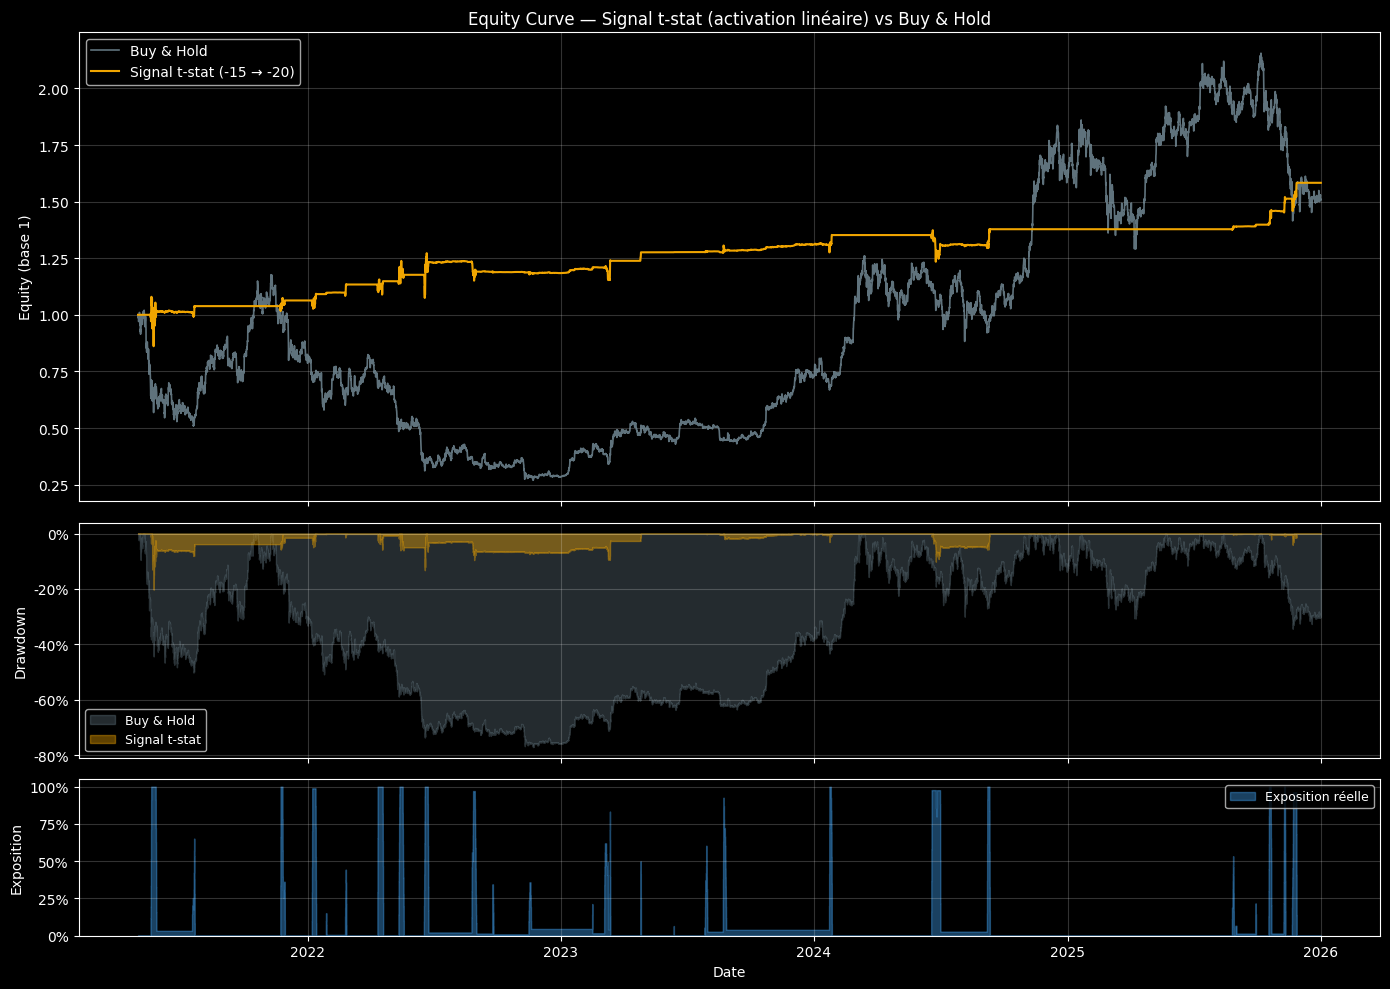

In [17]:
# ── Equity Curves + Drawdowns + Exposition ────────────────────────────────────
equity_strat = (1 + strat_returns).cumprod()
equity_bh    = (1 + bh_returns).cumprod()

dd_strat = (equity_strat / equity_strat.cummax()) - 1
dd_bh    = (equity_bh / equity_bh.cummax()) - 1

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 10), sharex=True,
                                     gridspec_kw={"height_ratios": [3, 1.5, 1]})

# Equity curves
ax1.plot(equity_bh.index, equity_bh.values, color="#78909c", linewidth=1.2,
         label="Buy & Hold", alpha=0.8)
ax1.plot(equity_strat.index, equity_strat.values, color="#f0a500", linewidth=1.5,
         label=f"Signal t-stat ({TSTAT_MIN} → {TSTAT_MAX})")
ax1.set_ylabel("Equity (base 1)")
ax1.set_title("Equity Curve — Signal t-stat (activation linéaire) vs Buy & Hold", fontsize=12)
ax1.legend(fontsize=10)
ax1.grid(alpha=0.2)

# Drawdowns
ax2.fill_between(dd_bh.index, 0, dd_bh.values, color="#78909c", alpha=0.3,
                 step="post", label="Buy & Hold")
ax2.fill_between(dd_strat.index, 0, dd_strat.values, color="#f0a500", alpha=0.4,
                 step="post", label="Signal t-stat")
ax2.set_ylabel("Drawdown")
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax2.legend(fontsize=9, loc="lower left")
ax2.grid(alpha=0.2)

# Exposition réelle (avec rebalancing)
ax3.fill_between(actual_exposure.index, 0, actual_exposure.values,
                 color="#42a5f5", alpha=0.4, step="post", label="Exposition réelle")
ax3.set_ylabel("Exposition")
ax3.set_xlabel("Date")
ax3.set_ylim(0, 1.05)
ax3.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
ax3.set_yticklabels(["0%", "25%", "50%", "75%", "100%"])
ax3.legend(fontsize=9, loc="upper right")
ax3.grid(alpha=0.2)

plt.tight_layout()
plt.show()

> Le signal peut aussi être exploité en mode retour à la moyenne

---
## Pour aller plus loin



- **Multi-actifs** — Tester le même signal sur plusieurs actifs
- **IC time-series vs cross-sectionnel** 



### Référence

📖 Grinold & Kahn, *Active Portfolio Management*

### Attention 
- Il faudrait utiliser un Train Set et Test Set car dans ce notebook pour simplifier je n'ai pas séparé les données ;)
